# **Clustering-based Course Recommender System**


In my previous work, I generated user profile vectors based on course ratings and genres. 

A user profile vector typically appears as a row vector in a matrix. For example, if the Database column for user2 has a value of 1, it indicates that user2 has a strong interest in database-related courses. With these user profile vectors, we can easily compute similarity among users based on their shared interests.


Furthermore, we can apply clustering algorithms such as K-means or DBSCAN to group users with similar learning interests.

For each user group, we can identify a list of popular courses. For instance, within the machine learning user cluster, we can count the most frequently enrolled courses. These are likely to be the most popular and high-quality machine learning courses since they are enrolled by many users interested in the subject.

If we determine that a user belongs to the machine learning group, we can recommend the most enrolled courses to them, and it's highly likely the user will find these recommendations interesting.


In this notebook, I'll implement clustering-based recommender system algorithms.


## Objectives


In this notebook, I will:


* Perform k-means clustering on the original user profile feature vectors
* Apply PCA (Principal Component Analysis) on user profile feature vectors to reduce dimensions
* Perform k-means clustering on the PCA transformed main components
* Generate course recommendations based on other group members' enrollment history


----


## Environment Setup


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
# Set a random state for reproducibility
rs = 123

### Loading the User Profile Dataset


First, I'll load the original user profile feature vectors:


In [3]:
import pandas as pd

user_profile_df = pd.read_csv("data/user_profile.csv")
user_profile_df.head()


,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


In [4]:
user_profile_df.shape

(33901, 15)

Now I'll list the feature names, which represent the user interest topics (course genres):


In [5]:
feature_names = list(user_profile_df.columns[1:])
feature_names

['Database',
 'Python',
 'CloudComputing',
 'DataAnalysis',
 'Containers',
 'MachineLearning',
 'ComputerVision',
 'DataScience',
 'BigData',
 'Chatbot',
 'R',
 'BackendDev',
 'FrontendDev',
 'Blockchain']

As we can see from the user profile dataset, we have approximately 33K unique users with interests in areas like `Database`, `Python`, `CloudComputing`, etc. Let's check the summary statistics for each feature.


In [6]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000
mean,1.064064e+06,5.518569,3.493791,2.307100,3.624701,0.998938,3.048022,0.001770,5.087343,4.750450,0.462995,1.017433,2.269461,0.315802,0.986844
std,4.972578e+05,7.611941,4.227254,3.841858,4.760135,2.351764,4.624004,0.072846,5.230697,7.216228,1.055186,2.342532,4.310752,1.363462,1.950585
min,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.813480e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.043907e+06,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.451159e+06,9.000000,6.000000,3.000000,6.000000,0.000000,3.000000,0.000000,9.000000,6.000000,0.000000,0.000000,3.000000,0.000000,2.000000
max,2.103039e+06,63.000000,18.000000,38.000000,48.000000,15.000000,39.000000,3.000000,32.000000,54.000000,6.000000,18.000000,54.000000,15.000000,12.000000


The original user profile feature vectors aren't normalized, which could cause issues when performing clustering and Principal Component Analysis (PCA). Therefore, I'll standardize the data.


In [7]:
# Use StandardScaler to make each feature with mean 0, standard deviation 1
# Instantiating a StandardScaler object
scaler = StandardScaler()

# Standardizing the selected features (feature_names) in the user_profile_df DataFrame
user_profile_df[feature_names] = scaler.fit_transform(user_profile_df[feature_names])

# Printing the mean and standard deviation of the standardized features
print("mean {} and standard deviation{} ".format(user_profile_df[feature_names].mean(), user_profile_df[feature_names].std()))

mean Database          -3.353495e-17
Python            -5.700942e-17
CloudComputing    -3.521170e-17
DataAnalysis      -7.671120e-17
Containers         3.353495e-18
MachineLearning    3.688845e-17
ComputerVision    -1.509073e-17
DataScience       -1.676748e-17
BigData            6.706990e-17
Chatbot           -6.874665e-17
R                  4.233788e-17
BackendDev         1.383317e-17
FrontendDev        5.051202e-17
Blockchain        -5.281755e-17
dtype: float64 and standard deviationDatabase           1.000015
Python             1.000015
CloudComputing     1.000015
DataAnalysis       1.000015
Containers         1.000015
MachineLearning    1.000015
ComputerVision     1.000015
DataScience        1.000015
BigData            1.000015
Chatbot            1.000015
R                  1.000015
BackendDev         1.000015
FrontendDev        1.000015
Blockchain         1.000015
dtype: float64 


In [8]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04
mean,1.064064e+06,-3.353495e-17,-5.700942e-17,-3.521170e-17,-7.671120e-17,3.353495e-18,3.688845e-17,-1.509073e-17,-1.676748e-17,6.706990e-17,-6.874665e-17,4.233788e-17,1.383317e-17,5.051202e-17,-5.281755e-17
std,4.972578e+05,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,2.000000e+00,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
25%,6.813480e+05,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
50%,1.043907e+06,-3.308757e-01,-1.168130e-01,-6.005256e-01,-1.312380e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-3.990622e-01,-3.811535e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
75%,1.451159e+06,4.573712e-01,5.928781e-01,1.803581e-01,4.990056e-01,-4.247674e-01,-1.038556e-02,-2.429612e-02,7.480294e-01,1.731609e-01,-4.387873e-01,-4.343370e-01,1.694715e-01,-2.316212e-01,5.194189e-01
max,2.103039e+06,7.551593e+00,3.431642e+00,9.290667e+00,9.322416e+00,5.953517e+00,7.775190e+00,4.115884e+01,5.145214e+00,6.824934e+00,5.247500e+00,7.249771e+00,1.200053e+01,1.076995e+01,5.646161e+00


The normalized user profile features are: 


In [9]:
features = user_profile_df.loc[:, user_profile_df.columns != 'user']
features

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419
2,2.427988,1.066006,4.084776,4.280467,-0.424767,5.828796,-0.024296,3.233395,1.281790,1.456642,5.542191,5.505047,2.702132,2.570116
3,-0.462250,-0.826504,-0.600526,-0.341319,-0.424767,-0.659184,-0.024296,-0.972608,-0.381153,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
4,0.063248,-0.826504,-0.600526,0.078843,-0.424767,-0.659184,-0.024296,-0.972608,0.173161,-0.438787,0.419453,-0.526473,-0.231621,-0.505930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33896,-0.330876,-0.116813,0.180358,0.499006,-0.424767,-0.659184,-0.024296,0.174484,-0.658311,-0.438787,2.127032,0.865416,-0.231621,1.032093
33897,-0.724999,-0.826504,-0.079936,-0.761482,-0.424767,-0.659184,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
33898,-0.330876,0.592878,0.961242,-0.761482,-0.424767,2.368540,-0.024296,0.748029,-0.658311,-0.438787,0.846348,-0.526473,-0.231621,-0.505930
33899,-0.724999,-0.826504,-0.600526,-0.761482,-0.424767,-0.226652,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930


I'll also save the user IDs for later recommendation tasks:


In [10]:
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']
user_ids

,user
0,2
1,4
2,5
3,7
4,8
...,...
33896,2102054
33897,2102356
33898,2102680
33899,2102983


### Performing K-means Clustering on User Profile Feature Vectors


With the user profile dataset ready, I'll use the `KMeans` class from scikit-learn to perform clustering on the user profile feature vectors.


For the `KMeans` algorithm, an important hyperparameter is the number of clusters `n_clusters`. A good approach to find the optimized `n_clusters` is to use grid search with a list of candidates and identify the one with the best clustering evaluation metrics, such as minimal `sum of squared distance`:


First, I'll determine the optimal number of clusters using the elbow method:


In [11]:
# Grid search for optimal n_clusters
kvec = list(range(1, 31))
inertia = []
for k in kvec:
    kmeans = KMeans(n_clusters = k, random_state = rs).fit(features)
    inertia.append(kmeans.inertia_)

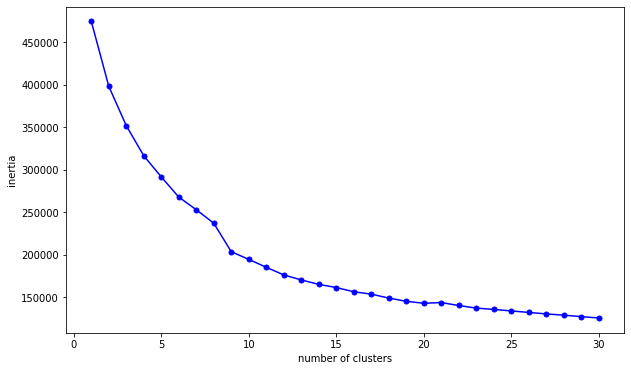

In [12]:
fig, ax = plt.subplots(figsize = (10,6))
plt.plot(kvec, inertia, '.', color = "blue", ms = 10)
plt.plot(kvec, inertia, color = "blue")
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.show()

The elbow plot above helps me visually identify the point where the metric starts to flatten, indicating the optimized number of clusters.


Now that I've identified the best number of clusters (20 in this case), I'll apply `KMeans()` again to generate cluster labels for all users.


In [13]:
kmeans = KMeans(n_clusters = 20, random_state = rs).fit(features)

In [14]:
cluster_labels = kmeans.labels_

The cluster labels generated are a list of integers indicating cluster indices. I'll use the following utility method to combine the cluster labels and user IDs into a dataframe, so I can see which cluster each user belongs to:


In [15]:
def combine_cluster_labels(user_ids, labels):
    # Convert labels to a DataFrame
    labels_df = pd.DataFrame(labels)    
    # Merge user_ids DataFrame with labels DataFrame based on index
    cluster_df = pd.merge(user_ids, labels_df, left_index=True, right_index=True)
    # Rename columns to 'user' and 'cluster'
    cluster_df.columns = ['user', 'cluster']
    return cluster_df

In [16]:
cluster_df = combine_cluster_labels(user_ids, cluster_labels)
cluster_df.head()

,user,cluster
0,2,7
1,4,11
2,5,7
3,7,6
4,8,15


Now each user has been assigned to a cluster, effectively creating multiple learning communities. Users within each community share very similar learning interests.


### Applying PCA on User Profile Feature Vectors for Dimension Reduction


In the previous step, I applied `KMeans` on the original user profile feature vectors which have 14 original features (the course genres).


In [17]:
# Extracting features from the user_profile_df DataFrame, excluding the 'user' column
features = user_profile_df.loc[:, user_profile_df.columns != 'user']

# Extracting user IDs from the user_profile_df DataFrame
user_ids = user_profile_df.loc[:, user_profile_df.columns == 'user']

# Creating a list of feature names by excluding the 'user' column name
feature_names = list(user_profile_df.columns[1:])

In [18]:
print(f"There are {len(feature_names)} features for each user profile.")

There are 14 features for each user profile.


If I plot a covariance matrix of the user profile feature vectors with 14 features, I can observe that some features are actually correlated:


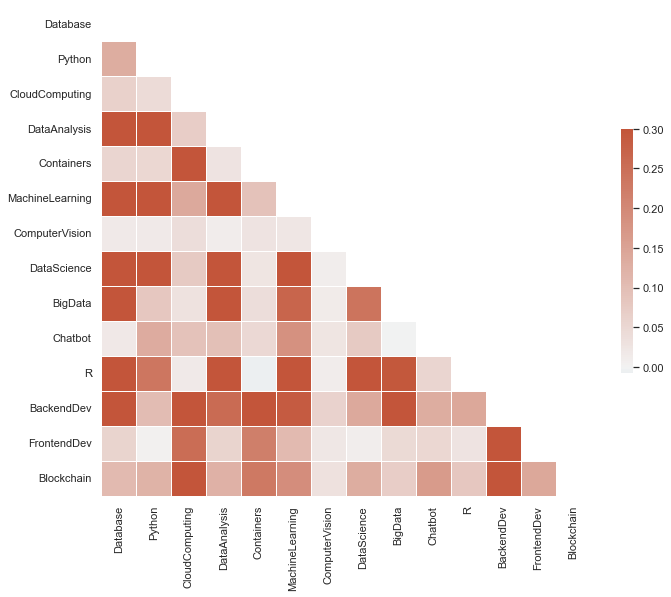

In [19]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = features.cov()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


plt.show()

For example, the feature `MachineLearning` and the feature `DataScience` are correlated. Such covariances among features suggest that I can apply PCA to find the main components (eigenvectors with max eigenvalues on the covariance matrix). 

By keeping only the independent main components, I can reduce the dimensions of the user profile feature vectors.


Now I'll apply the `PCA()` class from `scikit-learn` to find the main components in user profile feature vectors and see if I can reduce dimensions by keeping only the main components.


When calling the `PCA()` class, an important argument is `n_components`, which indicates how many components to keep in the PCA result. To find an optimized value of `n_components`, I'll do a grid search on a list of candidates (such as `range(1, 15)`) and calculate the ratio of accumulated variance for each candidate. 

If the accumulated variance ratio of a candidate `n_components` is larger than a threshold (e.g., 90%), then I can say the transformed `n_components` explain about 90% of the original data variance and can be considered an optimized component size.


Let's find the optimized `n_components` for PCA:


In [20]:
n_comps = list(range(1,15))
cum_var = []
for n_components in n_comps:
    pca = PCA(n_components = n_components, random_state = rs).fit(features)
    cum_var.append(pca.explained_variance_ratio_.sum())

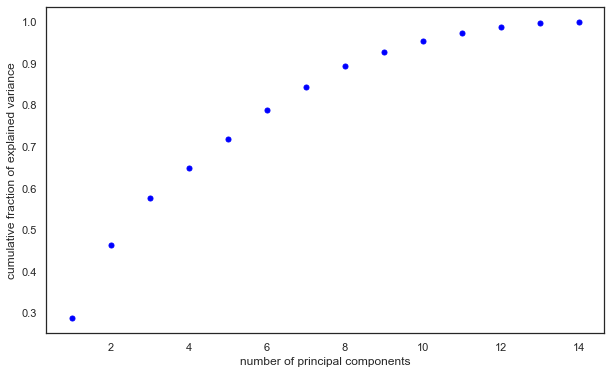

In [21]:
fig, ax = plt.subplots(figsize = (10,6))
plt.plot(n_comps, cum_var, '.', color = "blue", ms = 10)
plt.xlabel("number of principal components")
plt.ylabel("cumulative fraction of explained variance")
plt.show()

Now that I've found the optimized `n_component` value, I can apply PCA on the user profile feature vectors and reduce the 14 features into a smaller number of features.


Performing PCA to transform the original user profile features:


In [22]:
cum_var = np.array(cum_var)
ind_ncomps = 14 - len(cum_var[cum_var > 0.9])
print("Retaining " + str(ind_ncomps + 1) + " components explains " + str(cum_var[ind_ncomps]*100) + " percent of the variance.")

pca = PCA(n_components = (ind_ncomps + 1), random_state = rs).fit(features)
X_pca = pca.transform(features)

pc_df = pd.DataFrame({"user": user_ids.values.reshape(-1)})
for i in range(0, ind_ncomps + 1):
    colname = "PC" + str(i + 1)
    pc_df.insert(i + 1, colname, X_pca[:, i])

Retaining 9 components explains 92.72695591307681 percent of the variance.


In [23]:
pc_df

,user,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,2,17.772494,0.200681,1.730609,2.567359,-3.825814,-2.707154,0.681042,2.312613,0.868272
1,4,7.145199,-2.847481,2.358636,-0.576654,0.398803,0.134533,0.549769,0.469033,0.033405
2,5,11.363270,1.873619,-1.522077,1.076144,-1.711688,-0.883212,1.677582,2.937669,2.097639
3,7,-1.834033,-0.277462,0.564905,0.053470,-0.064440,-0.165757,0.030956,0.039519,0.210887
4,8,-1.049125,-0.684767,1.072765,0.006371,-0.005695,-0.118686,0.118559,0.559292,0.186379
...,...,...,...,...,...,...,...,...,...,...
33896,2102054,0.633824,0.108815,-0.388871,-0.122665,-0.098364,-0.358333,1.752049,1.486542,-0.523600
33897,2102356,-2.095339,0.135058,0.244727,-0.088185,0.025081,-0.183641,0.046413,0.191709,0.260437
33898,2102680,0.625943,-0.547167,-1.692824,-0.630589,0.166632,-0.676244,-0.055100,0.582091,1.703193
33899,2102983,-2.036832,-0.153534,0.162852,0.082651,-0.126419,-0.255109,0.072496,0.113750,0.622900


The dataframe above shows my PCA-transformed user features. With this reduced dimensionality, I can now perform further analysis.


### Performing K-means Clustering on the PCA Transformed Feature Vectors


Now that I have the PCA components of the original profile vectors, I'll perform k-means clustering on them:


First, I'll find the optimal number of clusters for the PCA-transformed data:


In [24]:
kvec = list(range(1,31))
inertia = []
for k in kvec:
    kmeans_pc = KMeans(n_clusters = k, random_state = rs).fit(X_pca)
    inertia.append(kmeans_pc.inertia_)

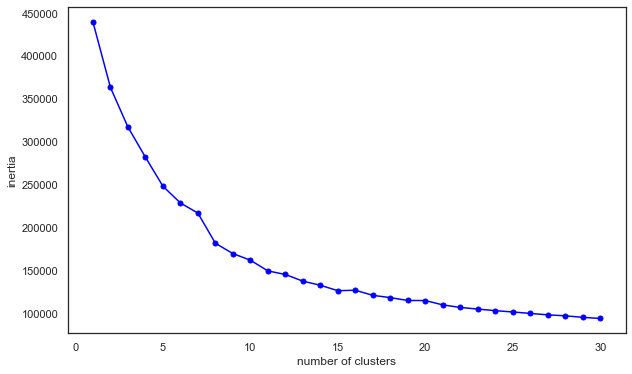

In [25]:
fig, ax = plt.subplots(figsize = (10,6))
plt.plot(kvec, inertia, '.', color = "blue", ms = 10)
plt.plot(kvec, inertia, color = "blue")
plt.xlabel("number of clusters")
plt.ylabel("inertia")
plt.show()

In [26]:
kmeans_pc = KMeans(n_clusters = 20, random_state = rs).fit(X_pca)
cluster_labels = kmeans_pc.labels_
pc_cluster_df = combine_cluster_labels(user_ids, cluster_labels)
pc_cluster_df.head()

,user,cluster
0,2,12
1,4,14
2,5,12
3,7,19
4,8,9


Great! Now all users have been assigned to learning interest groups, based on their PCA-transformed profile features. 


When a user is part of a group or community, it's likely they'll be interested in courses enrolled by other members within the same group.


### Generating Course Recommendations Based on Popular Courses in the Same Cluster


Next, I'll use a set of test users to demonstrate how to recommend new courses using a clustering-based recommender system:


In [27]:
# I'll use my local data file instead of the original URL
test_users_df = pd.read_csv("data/ratings.csv")[['user', 'item']]

# Displaying the first few rows of the DataFrame
test_users_df.head()

,user,item
0,1889878,CC0101EN
1,1342067,CL0101EN
2,1990814,ML0120ENv3
3,380098,BD0211EN
4,779563,DS0101EN


The test users dataset has only two columns: the user ID and the enrolled course ID. 


For each user, I'll find their cluster label using the k-means results from previous steps.


I can assign cluster labels to all test users by merging with the clustering labels (`cluster_df`):


In [28]:
test_users_labelled = pd.merge(test_users_df, cluster_df, left_on='user', right_on='user')
test_users_labelled.head()

,user,item,cluster
0,1889878,CC0101EN,13
1,1889878,ML0120ENv2,13
2,1889878,DV0151EN,13
3,1889878,HCC104EN,13
4,1889878,BD0211EN,13


From this dataframe, I can identify each user's enrolled courses and their cluster index.


By using `groupby` and `sum` aggregation, I can determine the enrollment count for each course in each group:


In [29]:
# Extracting the 'item' and 'cluster' columns from the test_users_labelled DataFrame
courses_cluster = test_users_labelled[['item', 'cluster']]

# Adding a new column 'count' with a value of 1 for each row in the courses_cluster DataFrame
courses_cluster['count'] = [1] * len(courses_cluster)

# Grouping the DataFrame by 'cluster' and 'item', aggregating the 'count' column with the sum function,
# and resetting the index to make the result more readable
courses_cluster_grouped = courses_cluster.groupby(['cluster','item']).agg(enrollments=('count','sum')).reset_index()
courses_cluster_grouped

,cluster,item,enrollments
0,0,AI0111EN,4
1,0,BC0101EN,126
2,0,BC0201EN,23
3,0,BC0202EN,10
4,0,BD0101EN,624
...,...,...,...
1993,19,TA0105EN,6
1994,19,TA0106EN,5
1995,19,TMP0105EN,26
1996,19,WA0101EN,44


Now I'll recommend unseen courses to each test user based on the popular courses in their cluster. I'll use an enrollment count threshold to determine if a course is popular in the cluster:


In [30]:
set(courses_cluster_grouped[(courses_cluster_grouped["cluster"] == 12) &
                                              (courses_cluster_grouped["enrollments"] > 100)]["item"].to_list())

{'BC0101EN',
 'BC0201EN',
 'BC0202EN',
 'BD0101EN',
 'BD0111EN',
 'BD0115EN',
 'BD0211EN',
 'CC0101EN',
 'CC0103EN',
 'CL0101EN',
 'CO0101EN',
 'CO0201EN',
 'DA0101EN',
 'DB0101EN',
 'DS0101EN',
 'DS0103EN',
 'DS0105EN',
 'DS0301EN',
 'DS0321EN',
 'DV0101EN',
 'DW0101EN',
 'ML0101ENv3',
 'ML0103EN',
 'ML0115EN',
 'ML0120ENv2',
 'PA0101EN',
 'PY0101EN',
 'RP0101EN',
 'SC0101EN',
 'ST0101EN',
 'WA0101EN'}

In [31]:
users = []
courses = []
for user_id, cluster_id in pc_cluster_df[["user", "cluster"]].values:
    cluster_courses = set(courses_cluster_grouped[(courses_cluster_grouped["cluster"] == cluster_id) &
                                              (courses_cluster_grouped["enrollments"] > 400)]["item"].to_list())
    user_courses = test_users_df[test_users_df["user"] == user_id]["item"].to_list()
    new_recs = cluster_courses.difference(user_courses)
    for course in new_recs:
        users.append(user_id)
        courses.append(course)
rec_df = pd.DataFrame({"user": users,
                       "rec_courses": courses})
rec_df

,user,rec_courses
0,2,CC0101EN
1,2,BC0201EN
2,2,DS0101EN
3,2,DS0105EN
4,2,ML0101ENv3
...,...,...
179803,2103039,BD0212EN
179804,2103039,BD0111EN
179805,2103039,BD0121EN
179806,2103039,BD0101EN


In [32]:
avg_recs = rec_df.groupby("user").size().values.mean()
print("On average, users are recommended " + str(avg_recs) + " courses.")

On average, users are recommended 5.926629091268664 courses.


In [33]:
# Load course information from local data
course_df = pd.read_csv("data/course_processed.csv")

top_courses = rec_df.groupby("rec_courses").size().sort_values(ascending = False).iloc[0:10]
top_course_names = []
for course_id in top_courses.index:
    top_course_names.append(course_df[course_df["COURSE_ID"] == course_id]["TITLE"].to_string())
top_courses_df = top_courses.to_frame(name = "times_recommended").reset_index().rename(columns = {"COURSE_ID": "course_id"})
top_courses_df.insert(1, "title", top_course_names)
top_courses_df

,rec_courses,title,times_recommended
0,BD0101EN,147 big data 101,14694
1,BD0111EN,181 hadoop 101,12552
2,BD0211EN,102 spark fundamentals i,12242
3,BD0115EN,97 mapreduce and yarn,9170
4,BD0212EN,37 spark fundamentals ii,8282
5,BD0131EN,96 moving data into hadoop,8195
6,BD0141EN,55 accessing hadoop data using hive,8163
7,BD0121EN,93 apache pig 101,7997
8,DS0101EN,176 introduction to data science,7543
9,PY0101EN,188 python for data science,6640


With these recommendation results, I can answer two important questions:


1. On average, how many new/unseen courses have been recommended to each user? (This is calculated above)
2. What are the most frequently recommended courses? (The top-10 list is shown above)


### Summary


In this part of my project, I've applied clustering algorithms to group users with similar interests and used PCA to reduce the dimensions of user feature vectors.

By assigning each user to an appropriate learning interest group, I've implemented a clustering-based course recommender system that makes recommendations based on group members' popular course choices. This approach provides a robust way to suggest new courses to users based on community preferences.
